# Chess RL — Resumable Self-Play Training

Runs the **self-play → train** loop one iteration at a time. Every *completed* iteration
saves a checkpoint and logs its metrics, so you can interrupt the kernel at any moment and
resume later with no corruption.

**Usage**
1. Launch Jupyter from your repo root (`~/semester_6/chess_bot`) so imports and the
   move-lookup path resolve.
2. Run sections **1–4** once per session (setup).
3. Run **section 5** whenever the laptop is idle. Press the interrupt button (■) to stop —
   the last completed iteration is always safe. Re-run section 5 (or sections 4+5 after a
   kernel restart) to resume from the latest checkpoint.
4. Use **section 6** to inspect progress.

## 1. Configuration

In [ ]:
import os

# ===== EDIT THESE =====
REPO_ROOT = os.path.abspath(".")   # assumes Jupyter was launched from the repo root

# Network — MUST match the checkpoints you load
NUM_RES_BLOCKS = 10
NUM_FILTERS    = 256

# Self-play
GAMES_PER_ITER  = 10     # higher (e.g. 10) for anything but testing
NUM_SIMULATIONS = 100    # lower (e.g. 30-50) for faster but noisier iterations
MAX_MOVES       = 100   # Could be set to 150 later
TEMP_THRESHOLD  = 30

# Training
TRAIN_EPOCHS     = 1
TRAIN_BATCH_SIZE = 32

# Parallel self-play across CPU cores.
# Serial (False) is the safe default and uses the in-memory network directly.
# If you set this True, see the note in section 3 about the worker import path.
USE_PARALLEL = False
NUM_WORKERS  = 4

# Persistence
SAVE_DATA = True   # also pickle the raw positions for each iteration

# ===== Derived paths =====
RUN_DIR  = os.path.join(REPO_ROOT, "reinforcement_learning", "training_runs")
CKPT_DIR = os.path.join(RUN_DIR, "checkpoints")
DATA_DIR = os.path.join(RUN_DIR, "data")
GAMES_DIR = os.path.join(RUN_DIR, "games")
LOG_DIR  = os.path.join(RUN_DIR, "logs")
LOG_FILE = os.path.join(LOG_DIR, "training.log")
ITER_CSV = os.path.join(LOG_DIR, "iterations.csv")
LOOKUP_PATH = os.path.join(REPO_ROOT, "reinforcement_learning", "move_lookup.json")

for d in (CKPT_DIR, DATA_DIR, LOG_DIR, GAMES_DIR):
    os.makedirs(d, exist_ok=True)

print("Checkpoints:", CKPT_DIR)
print("Logs:       ", LOG_DIR)

Checkpoints: /home/timle/semester_6/chess_bot/reinforcement_learning/training_runs/checkpoints
Logs:        /home/timle/semester_6/chess_bot/reinforcement_learning/training_runs/logs


## 2. Imports & logging

In [ ]:
import sys
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

import time
import glob
import csv
import pickle
import json
import logging
from datetime import datetime

import numpy as np

from reinforcement_learning.monte_carlo_tree_search.mcts_v2 import MCTS, SelfPlayGame
from reinforcement_learning.helpers.converter import Converter
from reinforcement_learning.networks.big_network import BigNetwork

# force=True resets handlers so re-running this cell doesn't duplicate log lines
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(message)s",
    datefmt="%H:%M:%S",
    handlers=[logging.FileHandler(LOG_FILE), logging.StreamHandler()],
    force=True,
)
log = logging.getLogger("train")


def log_iteration_csv(metrics: dict):
    """Append one iteration's metrics as a row in iterations.csv."""
    write_header = not os.path.exists(ITER_CSV)
    with open(ITER_CSV, "a", newline="") as f:
        w = csv.DictWriter(f, fieldnames=list(metrics.keys()))
        if write_header:
            w.writeheader()
        w.writerow(metrics)

## 3. Helper functions

`run_one_iteration` does self-play → train → save → return metrics. The checkpoint is
written only at the very end, which is what makes interrupting safe.

**Note on parallel self-play:** if you set `USE_PARALLEL = True`, the worker in
`mcts_v2.py` (`_selfplay_worker`) must import your network with the full package path —
`from reinforcement_learning.networks.big_network import BigNetwork` — and its
`SelfPlayGame(...)` call should pass `resign_threshold=None` (or your `SelfPlayGame`
default must already be `None`). The serial path below handles resign explicitly.

In [ ]:
def latest_iteration():
    """Highest completed iteration number on disk, or None if there are no checkpoints."""
    ckpts = glob.glob(os.path.join(CKPT_DIR, "iter_*.weights.h5"))
    if not ckpts:
        return None
    nums = []
    for c in ckpts:
        name = os.path.basename(c)
        nums.append(int(name[len("iter_"):-len(".weights.h5")]))
    return max(nums)


def flatten_games(games):
    """list[list[sample]] (per game) -> flat list[sample] (per position)."""
    return [s for game in games for s in game]


def generate_games(network, mcts, prev_weight_path):
    """Return a flat list of position samples from GAMES_PER_ITER self-play games."""
    records = []
    if USE_PARALLEL:
        from reinforcement_learning.monte_carlo_tree_search.mcts_v2 import play_games_parallel
        games = play_games_parallel(
            n_games=GAMES_PER_ITER, weight_path=prev_weight_path, lookup_path=LOOKUP_PATH,
            num_simulations=NUM_SIMULATIONS, num_res_blocks=NUM_RES_BLOCKS,
            num_filters=NUM_FILTERS, num_workers=NUM_WORKERS,
            max_moves=MAX_MOVES, temperature_threshold=TEMP_THRESHOLD,
        )
        # NOTE: the parallel worker doesn't return records yet
    else:
        games = []
        for g in range(GAMES_PER_ITER):
            game = SelfPlayGame(
                mcts, temperature_threshold=TEMP_THRESHOLD,
                max_moves=MAX_MOVES, resign_threshold=None,
            )
            games.append(game.play())
            records.append(game.record)
            log.info(f"  game {g + 1}/{GAMES_PER_ITER} done")
    return flatten_games(games), records

def save_games_json(iteration, records, prev_weight_path, num_positions, selfplay_seconds):
    payload = {
        "iteration": iteration,
        "timestamp": datetime.now().isoformat(timespec="seconds"),
        "generated_with_weights": os.path.basename(prev_weight_path),  # the net that played
        "config": {
            "games_per_iter": GAMES_PER_ITER,
            "num_simulations": NUM_SIMULATIONS,
            "max_moves": MAX_MOVES,
            "temperature_threshold": TEMP_THRESHOLD,
            "num_res_blocks": NUM_RES_BLOCKS,
            "num_filters": NUM_FILTERS,
        },
        "num_games": len(records),
        "num_positions": num_positions,
        "selfplay_seconds": round(selfplay_seconds, 1),
        "games": [{"game": i, **rec} for i, rec in enumerate(records)],
    }
    with open(os.path.join(GAMES_DIR, f"iter_{iteration}.json"), "w") as f:
        json.dump(payload, f, indent=2)

def run_one_iteration(iteration, network, mcts, converter, prev_weight_path):
    # 1. SELF-PLAY
    t0 = time.perf_counter()
    samples, records = generate_games(network, mcts, prev_weight_path)
    t_selfplay = time.perf_counter() - t0
    if not samples:
        raise RuntimeError("Self-play produced no positions — check max_moves / resign.")
    
    save_games_json(iteration, records, prev_weight_path, len(samples), t_selfplay)

    if SAVE_DATA:
        with open(os.path.join(DATA_DIR, f"iter_{iteration}.pkl"), "wb") as f:
            pickle.dump(samples, f)

    # 2. TRAIN
    t1 = time.perf_counter()
    board_tensors  = np.array([s["board_tensor"]  for s in samples])
    policy_targets = np.array([s["policy_target"] for s in samples])
    value_targets  = np.array([[s["value_target"]] for s in samples], dtype=np.float32)
    history = network.train(
        board_tensors, policy_targets, value_targets,
        epochs=TRAIN_EPOCHS, batch_size=TRAIN_BATCH_SIZE, verbose=0,
    )
    t_train = time.perf_counter() - t1

    # 3. CHECKPOINT (written last -> interrupting before here loses nothing saved)
    weight_path = os.path.join(CKPT_DIR, f"iter_{iteration}.weights.h5")
    network.save(weight_path)

    h = history.history
    def last(key):
        v = h.get(key)
        return round(float(v[-1]), 4) if v else None

    return {
        "iteration": iteration,
        "timestamp": datetime.now().isoformat(timespec="seconds"),
        "num_games": GAMES_PER_ITER,
        "num_positions": len(samples),
        "selfplay_seconds": round(t_selfplay, 1),
        "train_seconds": round(t_train, 1),
        "total_seconds": round(t_selfplay + t_train, 1),
        "loss": last("loss"),
        "policy_loss": last("policy_output_loss"),
        "value_loss": last("value_output_loss"),
        "weights_file": os.path.basename(weight_path),
    }


def run_iterations(num_iterations, network, mcts, converter):
    """Run up to num_iterations, resuming from the latest checkpoint.
    Interrupt the kernel any time; the last completed iteration is always saved."""
    start = latest_iteration()
    if start is None:
        raise RuntimeError("No checkpoint. Run section 4 first to create iter_0.")

    session_t0 = time.perf_counter()
    completed = 0
    log.info(f"=== Session start: resuming after iter_{start}, planning {num_iterations} iters ===")
    try:
        for it in range(start + 1, start + 1 + num_iterations):
            log.info(f"--- Iteration {it} starting ---")
            prev_path = os.path.join(CKPT_DIR, f"iter_{it - 1}.weights.h5")
            m = run_one_iteration(it, network, mcts, converter, prev_path)
            log_iteration_csv(m)
            log.info(
                f"Iteration {it} DONE in {m['total_seconds']}s "
                f"(self-play {m['selfplay_seconds']}s, train {m['train_seconds']}s) | "
                f"loss={m['loss']} | {m['num_positions']} positions | saved {m['weights_file']}"
            )
            completed += 1
    except KeyboardInterrupt:
        log.warning(
            f"Interrupted. {completed} iteration(s) this session. "
            f"Last safe checkpoint: iter_{latest_iteration()}."
        )
        print("\n⏹  Stopped cleanly — safe to use your laptop. Re-run to resume.")
    finally:
        mins = (time.perf_counter() - session_t0) / 60
        log.info(f"=== Session end: {completed} iterations, {mins:.1f} min ===")

In [ ]:
# THIS GETS USED TO ARCHIVE THE ENTIRE DIRECTORY TO GET TO A NEW STARTING POINT

# import shutil
# from datetime import datetime

# if os.path.isdir(RUN_DIR):
#     dst = RUN_DIR + "_archived_" + datetime.now().strftime("%Y%m%d_%H%M%S")
#     shutil.move(RUN_DIR, dst)
#     print("Archived old run to:", dst)

# for d in (CKPT_DIR, DATA_DIR, GAMES_DIR, LOG_DIR):
#     os.makedirs(d, exist_ok=True)
# print("Fresh, empty run dirs created.")

Archived old run to: /home/timle/semester_6/chess_bot/reinforcement_learning/training_runs_archived_20260614_230739
Fresh, empty run dirs created.


## 4. Build / resume the network (run once per session)

In [8]:
def setup_network():
    network = BigNetwork(num_res_blocks=NUM_RES_BLOCKS, num_filters=NUM_FILTERS)
    converter = Converter(lookup_path=LOOKUP_PATH)
    mcts = MCTS(network=network, converter=converter, num_simulations=NUM_SIMULATIONS)

    n = latest_iteration()
    if n is None:
        path = os.path.join(CKPT_DIR, "iter_0.weights.h5")
        network.save(path)
        log.info("No checkpoint found — saved random init as iter_0.")
    else:
        path = os.path.join(CKPT_DIR, f"iter_{n}.weights.h5")
        network.load(path)
        log.info(f"Resumed from {os.path.basename(path)}.")
    return network, converter, mcts


network, converter, mcts = setup_network()

22:12:02 | INFO | Resumed from iter_0.weights.h5.


## 5. Run training iterations

Run this whenever the laptop is free. Set the number high — it will stop when you interrupt
the kernel, and every completed iteration is checkpointed and logged.

In [9]:
run_iterations(1, network, mcts, converter)

22:12:08 | INFO | === Session start: resuming after iter_0, planning 1 iters ===
22:12:08 | INFO | --- Iteration 1 starting ---


  Move 20: 1nbqk2r/1pppbp2/7p/p5p1/Pr1PnP1P/1PQ5/2P1P1P1/RN1K1BNR w k - 1 11


22:12:39 | INFO |   game 1/5 done


  Game over after 31 moves: 1-0
  Move 20: rn3bnr/3kp1pp/pp1N1p2/2p4P/1PPp2b1/6P1/P2PPK2/R1BQ1BNR w - - 2 11
  Move 40: 5br1/r2kp2p/pp3ppB/n1p4P/PPPp2b1/3P2P1/4PK2/R2Q1BNR w - - 1 21
  Move 60: 3k1r2/r3p2p/pp3B2/n1p2ppP/PPPp4/3P2PN/4P3/R1Q2K1R w - - 3 31
  Move 80: 1r3B1k/4pr1p/pp1n4/2p2p1P/PP1p4/3P2P1/2Q1PK2/R5NR w - - 2 41


22:14:25 | INFO |   game 2/5 done


...

22:16:54 | INFO |   game 4/5 done


  Move 40: 2bq1k2/nr1pnp1r/pQ1Pp1pp/5N2/2P1N3/P4PPB/1P1bP2P/R1BK3R w - - 3 21
  Game over after 41 moves: 1-0
  Move 20: r1b1k1nr/Npp1qp1p/6pb/p2p4/3P1pP1/1P5B/P1PKPP1P/R2Q2NR w kq - 1 11
  Move 40: rq3kr1/2p2p1p/1p3npb/3pPN2/pP1P1pP1/7B/P1P1KP1P/1R2Q1NR w - - 7 21
  Move 60: r7/2p2pkp/1p5b/1q1pP1p1/1PPPnpPP/p4B2/P2QKP2/2R3NR w - - 3 31
  Move 80: 5rk1/2p2p1p/qp5b/4P1p1/1PPP1pPP/p5R1/P3KP2/R3Q1N1 w - - 4 41


22:18:47 | INFO |   game 5/5 done


  Move 100: 5N1k/2r2p2/1p6/2pPP3/1P3pPP/pq4R1/P2K1P2/R3Q3 w - - 1 51
  Game over after 100 moves: 1/2-1/2


22:19:06 | INFO | Iteration 1 DONE in 417.8s (self-play 399.2s, train 18.6s) | loss=21.2698 | 372 positions | saved iter_1.weights.h5
22:19:06 | INFO | === Session end: 1 iterations, 7.0 min ===


## 6. Inspect progress

,iteration,timestamp,num_games,num_positions,selfplay_seconds,train_seconds,total_seconds,loss,policy_loss,value_loss,weights_file
0,1,2026-06-14T22:19:06,5,372,399.2,18.6,417.8,21.2698,20.4958,0.6381,iter_1.weights.h5


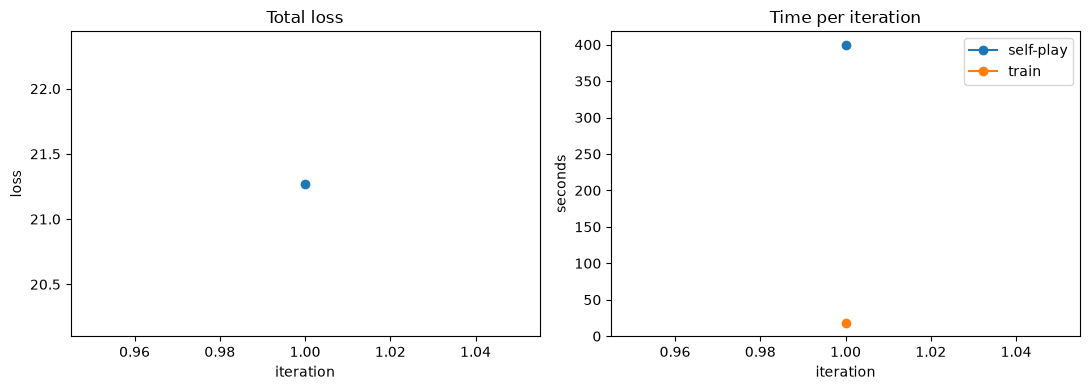

In [10]:
try:
    import pandas as pd
    df = pd.read_csv(ITER_CSV)
    display(df.tail(20))
    try:
        import matplotlib.pyplot as plt
        fig, ax = plt.subplots(1, 2, figsize=(11, 4))
        ax[0].plot(df["iteration"], df["loss"], marker="o")
        ax[0].set(title="Total loss", xlabel="iteration", ylabel="loss")
        ax[1].plot(df["iteration"], df["selfplay_seconds"], marker="o", label="self-play")
        ax[1].plot(df["iteration"], df["train_seconds"], marker="o", label="train")
        ax[1].set(title="Time per iteration", xlabel="iteration", ylabel="seconds")
        ax[1].legend()
        plt.tight_layout(); plt.show()
    except Exception as e:
        print("Plotting skipped:", e)
except FileNotFoundError:
    print("No iterations logged yet — run section 5 first.")